In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit

In [4]:
path = Path.cwd().joinpath("readings.csv")
csv = pd.read_csv(path)

print(csv.head())

   Voltage  Resistance   Current  Reading 1  Reading 2
0     26.7        47.0  0.568085        132        188
1     26.7        41.3  0.646489        138        219
2     26.7        31.3  0.853035        199        270
3     26.7        22.5  1.186667        291        385
4     26.7        18.8  1.420213        360        411


In [5]:
reading_1_offset = -20
reading_2_offset = 57
csv["Voltage 1"] = (csv["Reading 1"] - reading_1_offset) * 0.0001875
csv["Voltage 2"] = (csv["Reading 2"] - reading_2_offset) * 0.0001875
csv.head(20)

,Voltage,Resistance,Current,Reading 1,Reading 2,Voltage 1,Voltage 2
0,26.7,47.0,0.568085,132,188,0.028500,0.024563
1,26.7,41.3,0.646489,138,219,0.029625,0.030375
2,26.7,31.3,0.853035,199,270,0.041063,0.039938
3,26.7,22.5,1.186667,291,385,0.058313,0.061500
4,26.7,18.8,1.420213,360,411,0.071250,0.066375
5,26.6,14.7,1.809524,452,516,0.088500,0.086063
6,26.6,9.1,2.923077,733,790,0.141187,0.137437
7,26.5,4.8,5.520833,1386,1442,0.263625,0.259688
8,26.3,2.3,11.434783,2359,2431,0.446063,0.445125
9,26.3,2.3,11.434783,2326,2390,0.439875,0.437438


Average Voltage difference:  -0.006579545454545463


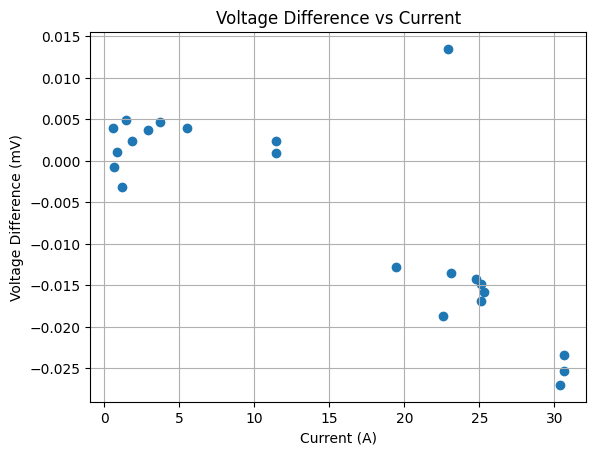

In [6]:
csv["Adjusted Voltage 1"] = csv["Voltage 1"]
csv["Adjusted Voltage 2"] = csv["Voltage 2"]
csv["Voltage Difference"] = csv["Adjusted Voltage 1"] - csv["Adjusted Voltage 2"]

print("Average Voltage difference: ", csv["Voltage Difference"].mean())

plt.scatter(csv['Current'], csv["Voltage Difference"])
plt.xlabel("Current (A)")
plt.ylabel("Voltage Difference (mV)")
plt.title("Voltage Difference vs Current")
plt.grid()

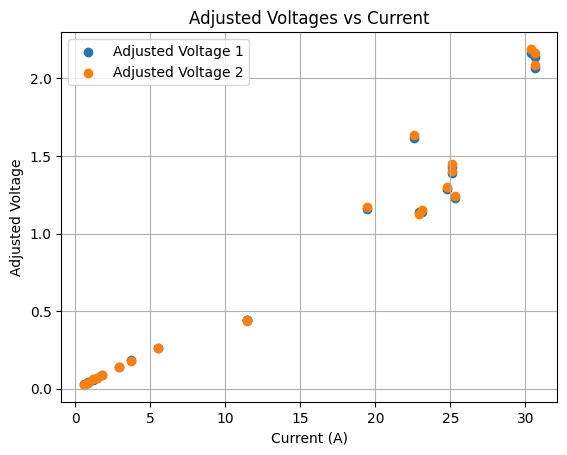

In [7]:
# Plotting 2 seperate lines for the adjusted Voltages
plt.figure()
plt.scatter(csv['Current'], csv["Adjusted Voltage 1"], label="Adjusted Voltage 1")
plt.scatter(csv['Current'], csv["Adjusted Voltage 2"], label="Adjusted Voltage 2")
plt.xlabel("Current (A)")
plt.ylabel("Adjusted Voltage")
plt.title("Adjusted Voltages vs Current")
plt.legend()
plt.grid()
plt.show()

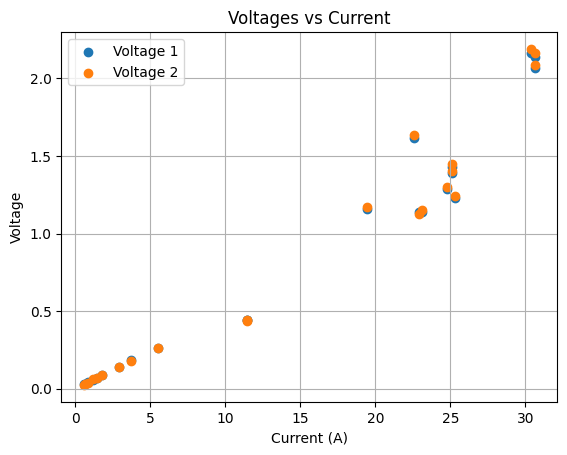

In [8]:
# Plotting 2 seperate lines for the adjusted voltages
plt.figure()
plt.scatter(csv['Current'], csv["Voltage 1"], label="Voltage 1")
plt.scatter(csv['Current'], csv["Voltage 2"], label="Voltage 2")
plt.xlabel("Current (A)")
plt.ylabel("Voltage")
plt.title("Voltages vs Current")
plt.legend()
plt.grid()
plt.show()

In [9]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func = lambda x, a, b, c: a * x**2 + b * x + c
params, _ = curve_fit.curve_fit(curve_fit_func, csv['Consolidated Voltage'], csv['Current'])
a, b, c = params
print(f"Fitted curve parameters: a={a}, b={b}, c={c}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x + {c:.8f}")
print(f"Zero current Voltage: {c:.4f} V")

#R-squared value
residuals = csv['Current'] - curve_fit_func(csv['Consolidated Voltage'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Current'] - np.mean(csv['Current']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=-5.301523596682817, b=25.402702584482252, c=-0.13405368397120265
Fitted curve: y = -5.30152360 * x**2 + 25.40270258*x + -0.13405368
Zero current Voltage: -0.1341 V
R-squared value: 0.9851


In [10]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_zeroed = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_zeroed, csv['Consolidated Voltage'], csv['Current'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = csv['Current'] - curve_fit_func_zeroed(csv['Consolidated Voltage'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Current'] - np.mean(csv['Current']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=-5.210641958173237, b=25.157930107066665
Fitted curve: y = -5.21064196 * x**2 + 25.15793011*x
Zero current Voltage: 0.0000 V
R-squared value: 0.9851


In [11]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_linear = lambda x, a, b: a * x + b
params, _ = curve_fit.curve_fit(curve_fit_func_linear, csv['Consolidated Voltage'], csv['Current'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x + {b:.8f}")
print(f"Zero current Voltage: {b:.4f} V")

#R-squared value
residuals = csv['Current'] - curve_fit_func_linear(csv['Consolidated Voltage'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Current'] - np.mean(csv['Current']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=14.901752000004992, b=1.9994331440368993
Fitted curve: y = 14.90175200 * x + 1.99943314
Zero current Voltage: 1.9994 V
R-squared value: 0.9446


In [12]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_sigmoid = lambda x, L, k, x0: L / (1 + np.exp(-k * (x - x0)))
p0 = [30000, 0.1, 50]

params, _ = curve_fit.curve_fit(curve_fit_func_sigmoid, csv['Consolidated Voltage'], csv['Current'], p0=p0)
L, k, x0 = params
print(f"Fitted curve parameters: L={L}, k={k}, x0={x0}")
print(f"Fitted curve: y = {L:.8f} / (1 + np.exp(-{k:.8f} * (x - {x0:.8f})))")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = csv['Current'] - curve_fit_func_sigmoid(csv['Consolidated Voltage'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Current'] - np.mean(csv['Current']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: L=29.247221008514696, k=3.1167212590339055, x0=0.7647993325002803
Fitted curve: y = 29.24722101 / (1 + np.exp(-3.11672126 * (x - 0.76479933)))
Zero current Voltage: 0.0000 V
R-squared value: 0.9676


In [13]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_ended = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_ended, np.append(csv['Consolidated Voltage'], 5), np.append(csv['Current'], 100))
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = np.append(csv['Current'] - curve_fit_func_ended(csv['Consolidated Voltage'], *params), 100 - curve_fit_func_ended(5, *params))
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((np.append(csv['Current'], 100) - np.mean(np.append(csv['Current'], 100)))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=0.9022528926769144, b=15.063455265150399
Fitted curve: y = 0.90225289 * x**2 + 15.06345527*x
Zero current Voltage: 0.0000 V
R-squared value: 0.9731


In [14]:
ideal_linear = lambda x: 5 / 100 * x
residual_sum_squares = np.sum((csv['Current'] - ideal_linear(csv['Consolidated Voltage']))**2)
total_sum_squares = np.sum((csv['Current'] - np.mean(csv['Current']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")

R-squared value: -1.6129


In [16]:
fitted_squared = lambda x: -5.30152360 * x**2 + 25.40270258*x + -0.13405368                     # R-squared: 0.9851
fitted_squared_zeroed = lambda x: -5.21064196 * x**2 + 25.15793011*x                      # R-squared: 0.9851
fitted_linear = lambda x:  14.90175200 * x + 1.99943314                                 # R-squared: 0.9446
fitted_sigmoid = lambda x: 29.24722101 / (1 + np.exp(-3.11672126 * (x - 0.76479933)))   # R-squared: 0.9676
fitted_ended = lambda x: 0.90225289 * x**2 + 15.06345527*x                                # R-squared: 0.9731
fitted_ideal_linear = lambda x: 5 / 100 * x                                     # R-squared: 

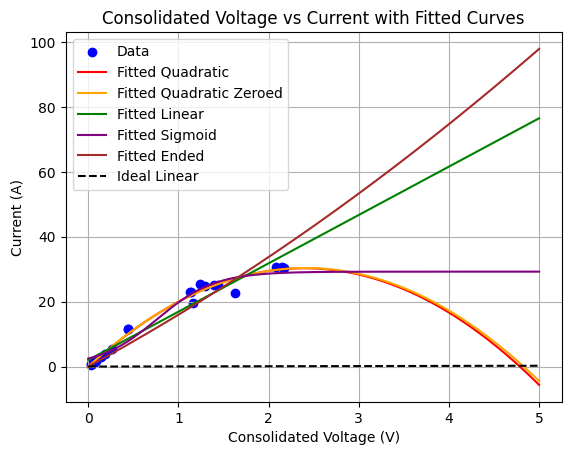

In [18]:
plt.scatter(csv['Consolidated Voltage'], csv['Current'], label="Data", color='blue')

x_values = np.linspace(0, 5, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Consolidated Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()

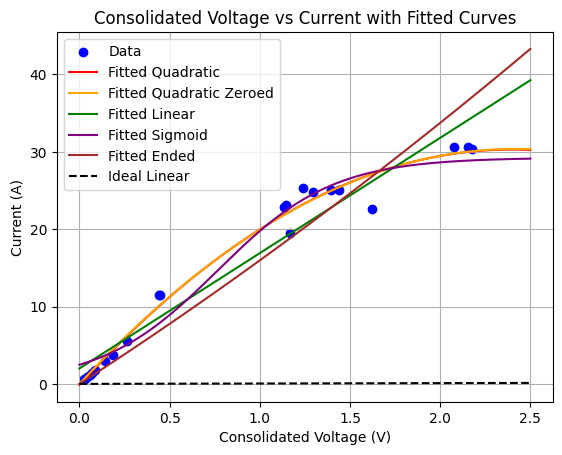

In [20]:
plt.scatter(csv['Consolidated Voltage'], csv['Current'], label="Data", color='blue')

x_values = np.linspace(0, 2.5, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Consolidated Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()

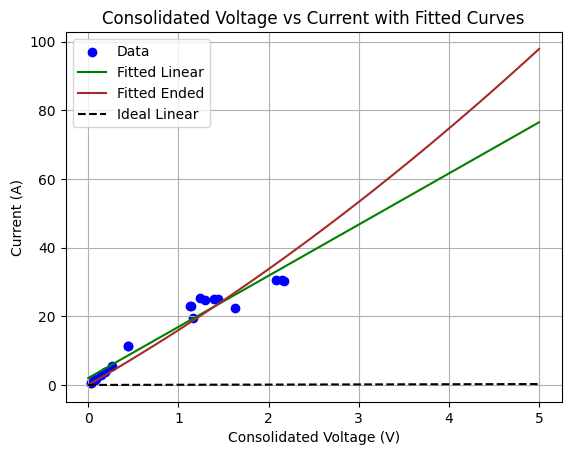

In [ ]:
# Shortlisted
#fitted_linear = lambda x:  14.90175200 * x + 1.99943314                                 # R-squared: 0.9446
# fitted_ended = lambda x:                                  # R-squared: 0.9731

plt.scatter(csv['Consolidated Voltage'], csv['Current'], label="Data", color='blue')

x_values = np.linspace(0, 5, 100)
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Consolidated Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()